In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv("student_performance_updated_1000.csv")
df.sample(5)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
971,1046.0,Maria Edwards,Male,85.0,NaN,70.0,1.0,High,87.0,0.3,72.0,False
364,6622.0,John Carter,Male,82.0,17.0,88.0,2.0,Medium,68.0,4.2,85.0,True
864,4871.0,Mrs. Cindy Sharp DVM,Male,70.0,17.0,82.0,NaN,Low,92.0,1.2,61.0,True
788,1985.0,Dawn Luna,Female,88.0,22.0,NaN,NaN,Medium,92.0,2.9,82.0,False
338,8909.0,Francisco Williams,Male,70.0,10.0,86.0,0.0,High,80.0,0.5,63.0,True


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


### Data Cleaning :-


In [26]:
# checking the shape of the dataset
df.shape

(1000, 12)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
# checking the number of null values in "Gender" column
df["Gender"].isnull().sum()

np.int64(48)

In [29]:
# making a copy of the dataset for EDA
df1 = df.copy()
df1.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


<Axes: xlabel='Gender', ylabel='count'>

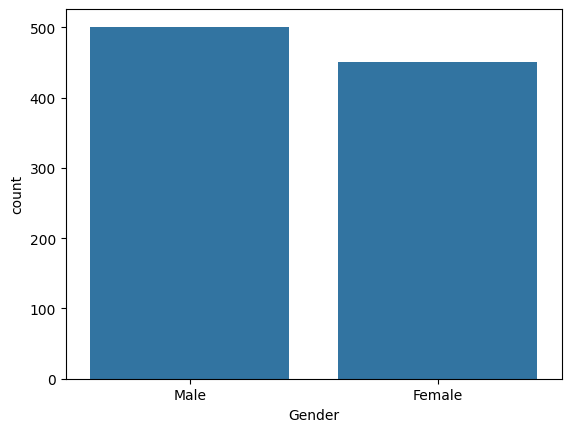

In [30]:
# visualizing the count of Gender column using countplot
sns.countplot(x = "Gender", data = df1)

In [31]:
# filling null values in Gender column with the mode value
df1["Gender"].fillna(df["Gender"].mode()[0], inplace = True)
df1['Gender'].isnull().sum()

np.int64(0)

In [32]:
# checking the number of null values in "AttendanceRate" column
df1["AttendanceRate"].isnull().sum()

np.int64(40)

In [33]:
# because attendance rate is a numerical column, we will fill the null values with the mean value of the column
df1["AttendanceRate"].fillna(df1["AttendanceRate"].mean(), inplace = True)
df1["AttendanceRate"].isnull().sum()

np.int64(0)

In [34]:
# because StudyHoursPerWeek is a numerical column, we will fill the null values with the mean value of the column
df1["StudyHoursPerWeek"].fillna(df1["StudyHoursPerWeek"].mean(), inplace = True)
df1["StudyHoursPerWeek"].isnull().sum()

np.int64(0)

In [35]:
# because PreviousGrade is a numerical column, we will fill the null values with the mean value of the column
df1["PreviousGrade"].fillna(df1["PreviousGrade"].mean(), inplace = True)
df1["PreviousGrade"].isnull().sum()

np.int64(0)

In [36]:
# filling ExtracurricularActivities null values with 0 because it is a categorical column and 0 indicates that the student does not participate in any extracurricular activities
df1["ExtracurricularActivities"].fillna(0, inplace = True)
df1["ExtracurricularActivities"].isnull().sum()

np.int64(0)

In [37]:
df["ExtracurricularActivities"].value_counts()

ExtracurricularActivities
1.0    287
2.0    266
3.0    212
0.0    192
Name: count, dtype: int64

In [38]:
# checking the number of null values in "ParentalSupport" column
df1["ParentalSupport"].isnull().sum()

np.int64(22)

In [39]:
df1["ParentalSupport"].value_counts()

ParentalSupport
High      345
Medium    328
Low       305
Name: count, dtype: int64

In [40]:
# filling null values to "Medium" because if the support is not mentioned then we can assume that it as medium support
df1["ParentalSupport"].fillna("Medium", inplace = True)
df1["ParentalSupport"].isnull().sum()

np.int64(0)

In [41]:
# filling null values in "final grade" column with the mean value of the column because it is a numerical column
df1["FinalGrade"].fillna(df1["FinalGrade"].mean(), inplace = True)
df1["FinalGrade"].isnull().sum()

np.int64(0)

In [42]:
# filling null values in "Study Hours" & "Attendance (%)" columns with the mean value of the respective columns because they are numerical columns
df1["Study Hours"].fillna(df1["Study Hours"].mean(), inplace = True)
df1["Attendance (%)"].fillna(df1["Attendance (%)"].mean(), inplace = True)

In [43]:
df1["Study Hours"].isnull().sum()

np.int64(0)

In [44]:
df1["Attendance (%)"].isnull().sum()

np.int64(0)

In [45]:
# checking the number of null values in "Online Classes Taken" column
df1["Online Classes Taken"].isnull().sum()

np.int64(25)

<Axes: xlabel='Online Classes Taken', ylabel='count'>

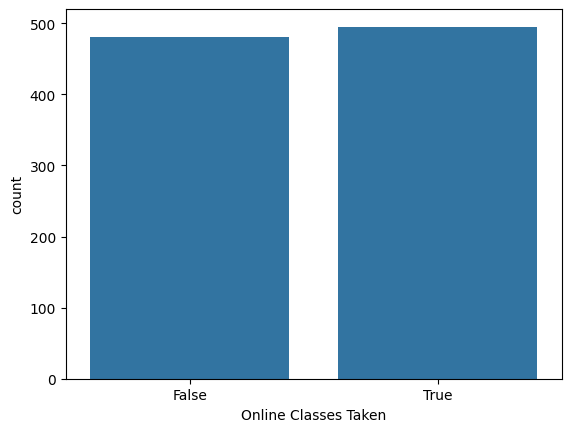

In [46]:
# visualizing the count of Online Classes Taken column using countplot
sns.countplot(x = "Online Classes Taken", data = df1)

In [47]:
df1["Online Classes Taken"].value_counts()

Online Classes Taken
True     495
False    480
Name: count, dtype: int64

In [48]:
# filling the null values in the "Online Classes Taken" column with the mode
df1["Online Classes Taken"].fillna(df1["Online Classes Taken"].mode()[0], inplace=True)
df1["Online Classes Taken"].isnull().sum()

np.int64(0)

In [49]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     1000 non-null   object 
 3   AttendanceRate             1000 non-null   float64
 4   StudyHoursPerWeek          1000 non-null   float64
 5   PreviousGrade              1000 non-null   float64
 6   ExtracurricularActivities  1000 non-null   float64
 7   ParentalSupport            1000 non-null   object 
 8   FinalGrade                 1000 non-null   float64
 9   Study Hours                1000 non-null   float64
 10  Attendance (%)             1000 non-null   float64
 11  Online Classes Taken       1000 non-null   bool   
dtypes: bool(1), float64(8), object(3)
memory usage: 87.0+ KB


In [50]:
# checking the number of null values in "Name" column
df1["Name"].isnull().sum()

np.int64(34)

In [51]:
# filling the null values in "Name" column with "Unknown" because it is a categorical column and if the name is not mentioned then we can assume it as unknown
df1["Name"].fillna("Unknown", inplace = True)
df1["Name"].isnull().sum()

np.int64(0)

In [52]:
df1["StudentID"].isnull().sum() 

np.int64(40)

In [53]:
# Because StudentID is not a useful feature for prediction, we can drop this column from the dataset
df1.drop("StudentID", axis = 1, inplace = True)

In [54]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       1000 non-null   object 
 1   Gender                     1000 non-null   object 
 2   AttendanceRate             1000 non-null   float64
 3   StudyHoursPerWeek          1000 non-null   float64
 4   PreviousGrade              1000 non-null   float64
 5   ExtracurricularActivities  1000 non-null   float64
 6   ParentalSupport            1000 non-null   object 
 7   FinalGrade                 1000 non-null   float64
 8   Study Hours                1000 non-null   float64
 9   Attendance (%)             1000 non-null   float64
 10  Online Classes Taken       1000 non-null   bool   
dtypes: bool(1), float64(7), object(3)
memory usage: 79.2+ KB


### EDA (Exploratory Data Analysis) :-


In [55]:
df1.describe()

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,85.510417,17.630526,77.598759,1.455000,80.030208,2.406967,77.248175
std,7.183836,6.113157,9.839977,1.069167,9.301647,1.600686,18.897991
min,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,64.000000
50%,85.510417,17.630526,78.000000,1.000000,80.030208,2.453484,77.000000
75%,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [56]:
df1.sample(5)

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
471,Mary Warren,Female,95.0,12.0,77.0,1.0,High,62.0,3.100000,79.0,True
164,Adam Carlson,Female,85.0,22.0,88.0,3.0,Medium,62.0,0.900000,92.0,True
94,Jeffrey Howard,Male,88.0,17.0,77.0,2.0,High,88.0,2.406967,95.0,True
917,Allison Novak,Female,91.0,17.0,85.0,2.0,Medium,88.0,4.300000,85.0,False
195,Shirley Jackson,Male,78.0,20.0,60.0,1.0,Medium,72.0,4.700000,98.0,True


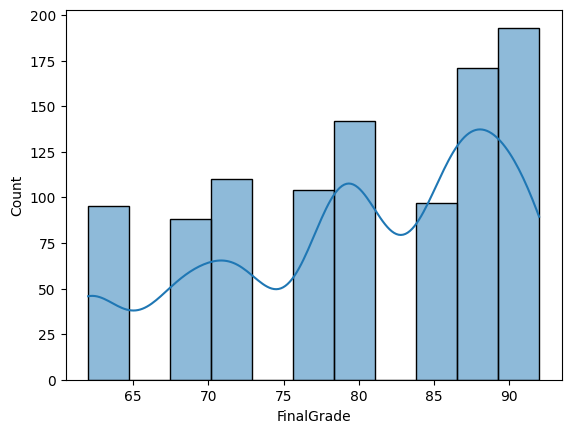

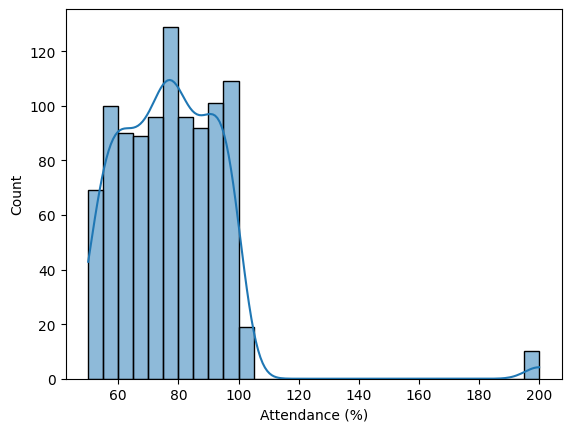

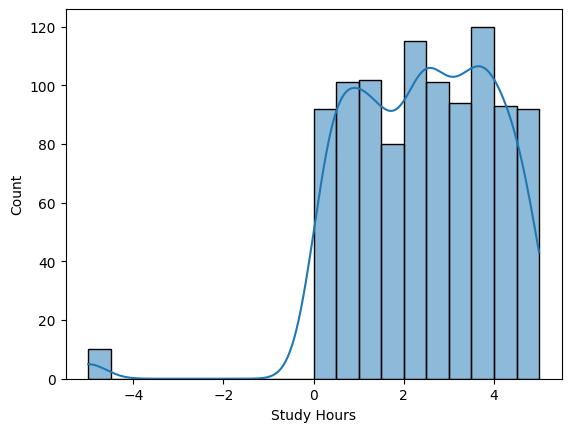

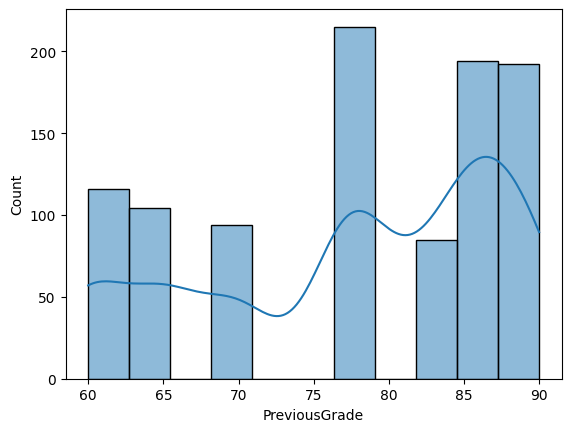

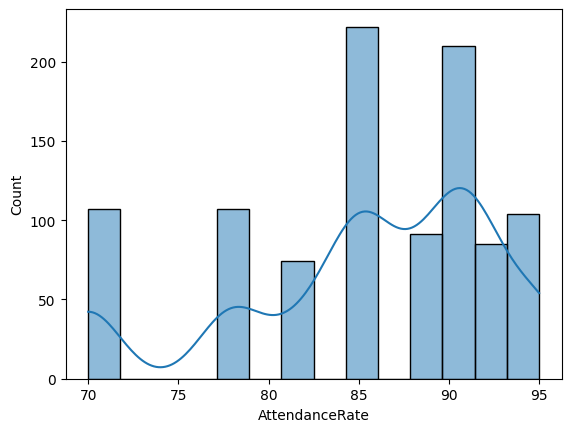

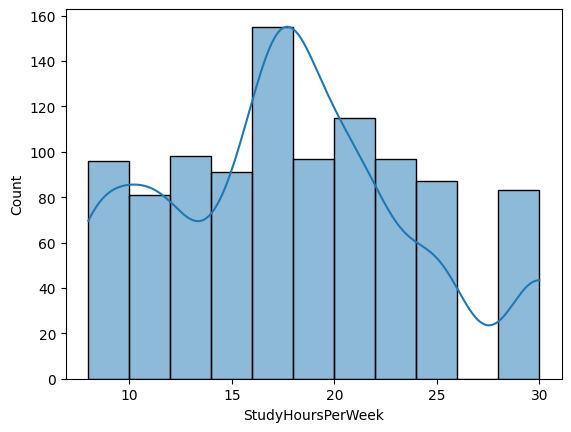

In [57]:
cols = ["FinalGrade", "Attendance (%)", "Study Hours", "PreviousGrade", "AttendanceRate", "StudyHoursPerWeek"]

for col in cols:
    sns.histplot(x = col, data = df1, kde = True)
    plt.show()

In [58]:
# Making sure that the values in "Attendance (%)" column do not exceed 100 because attendance percentage cannot be more than 100%
df1['Attendance (%)'] = df1['Attendance (%)'].clip(upper=100)

<Axes: xlabel='Attendance (%)', ylabel='Count'>

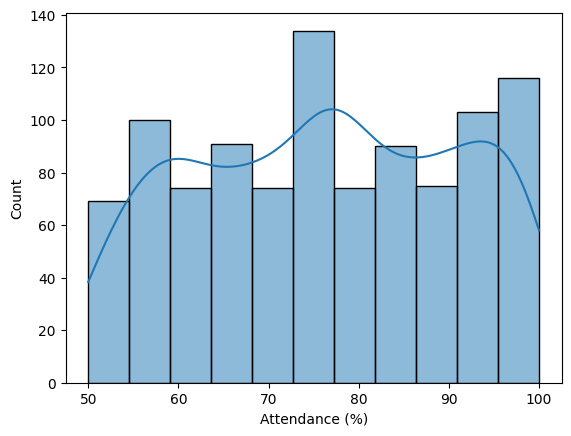

In [59]:
sns.histplot(df1["Attendance (%)"], kde = True)

In [60]:
# Making sure that the values in "Study Hours" column do not go below 0 because study hours cannot be negative
df1['Study Hours'] = df1['Study Hours'].clip(lower=0)

<Axes: xlabel='Study Hours', ylabel='Count'>

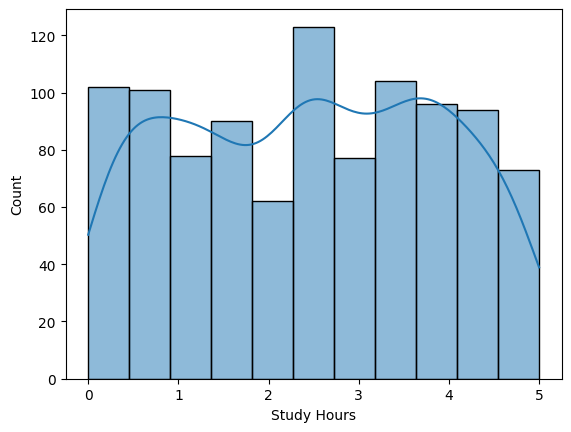

In [61]:
sns.histplot(x = "Study Hours", data = df1, kde = True)

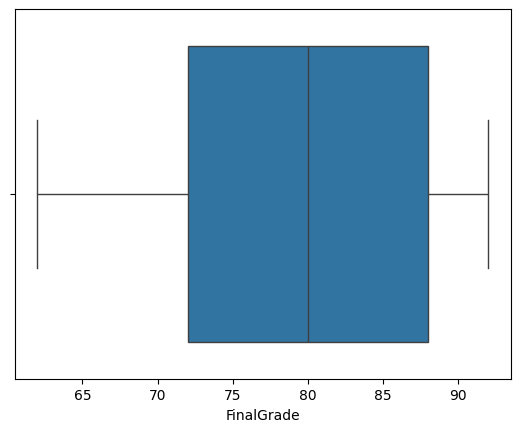

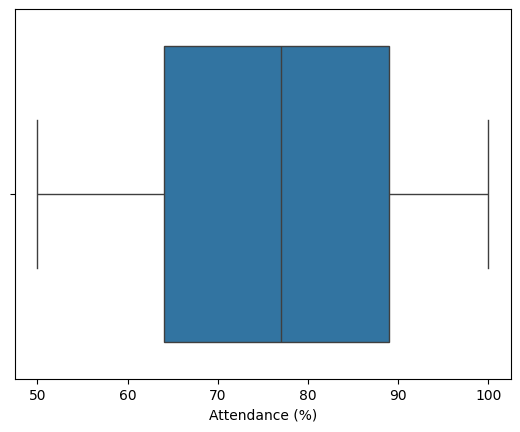

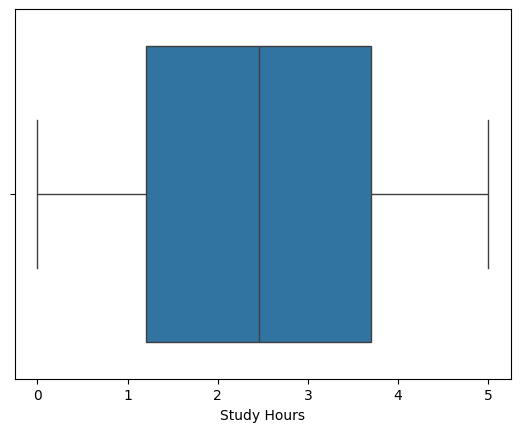

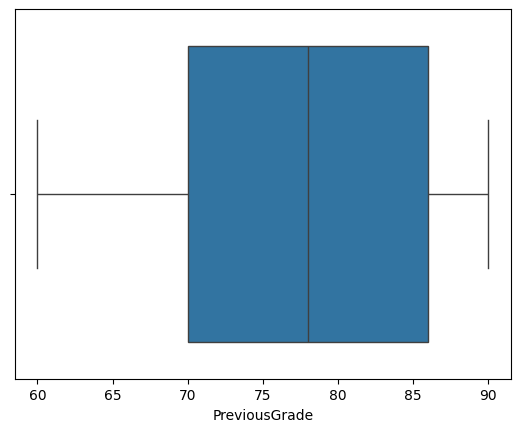

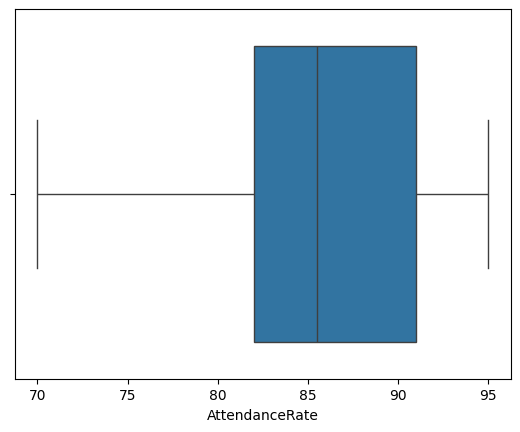

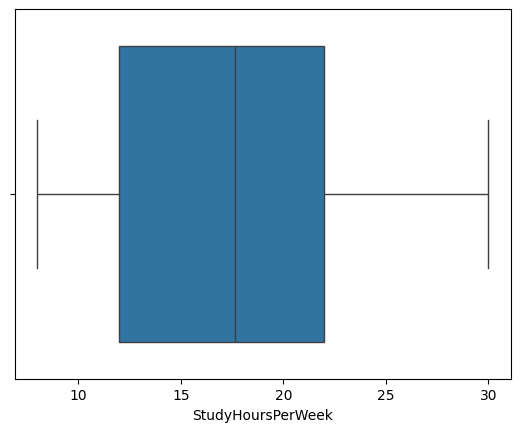

In [62]:
# visualizing the boxplot for the numerical columns to check for outliers
for col in cols:
    sns.boxplot(x = col, data = df1)
    plt.show()

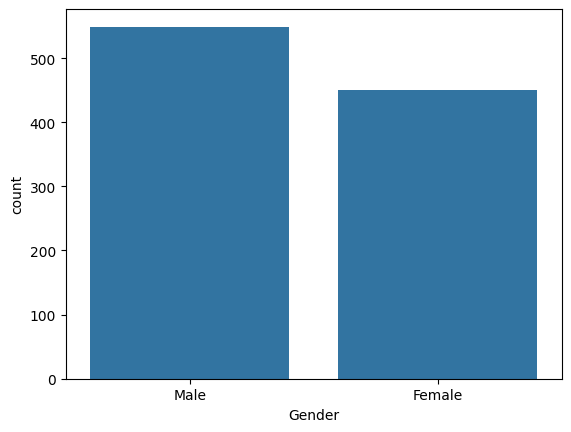

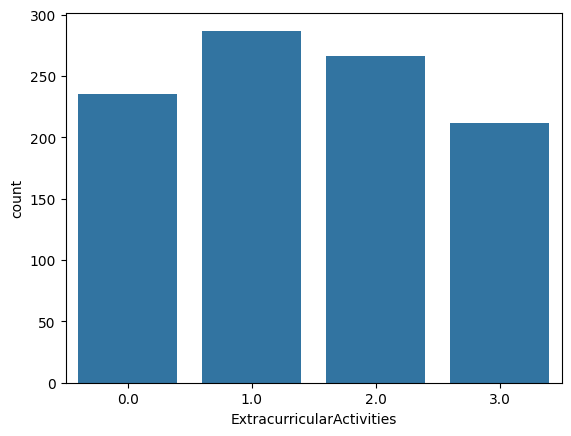

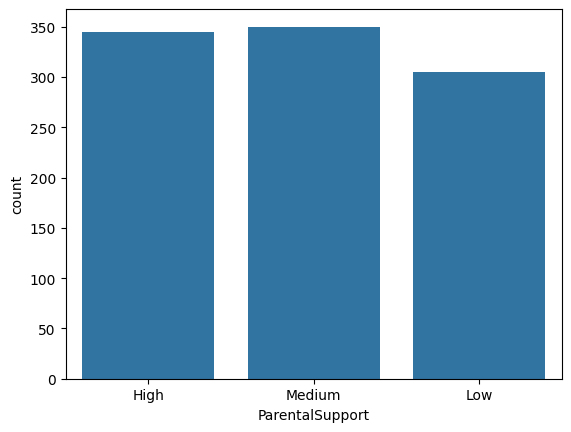

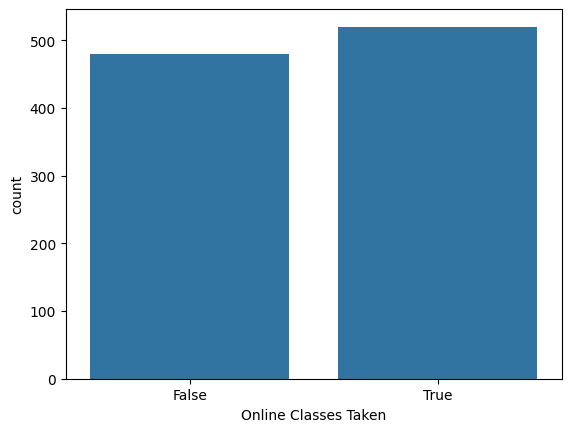

In [63]:
# visualizing all categorical columns using countplot
catCols = ["Gender", "ExtracurricularActivities", "ParentalSupport", "Online Classes Taken"]
for col in catCols:
    sns.countplot(x = col, data = df1)
    plt.show()

<Axes: >

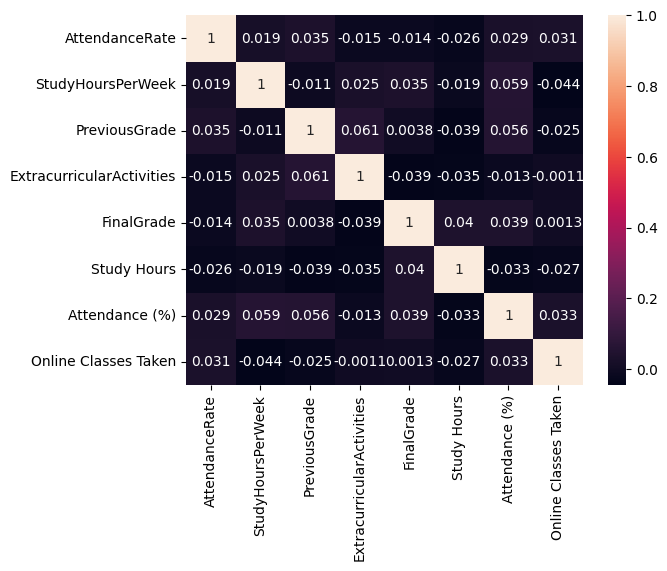

In [64]:
# visualizing the correlation between the numerical columns using heatmap
sns.heatmap(df1.corr(numeric_only=True), annot = True)

### ONE Hot Emcoding :-


In [65]:
dfT = df1.copy()

In [66]:
dfT.head()

,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,John,Male,85.000000,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Sarah,Female,90.000000,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Alex,Male,78.000000,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Michael,Male,92.000000,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Emma,Female,85.510417,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [67]:
# appling one hot encoding to the categorical columns
dfT = pd.get_dummies(dfT, columns = ["Gender", "ParentalSupport"])

In [68]:
dfT.head()

,Name,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,Gender_Female,Gender_Male,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,John,85.000000,15.0,78.0,1.0,80.0,4.8,59.0,False,False,True,True,False,False
1,Sarah,90.000000,20.0,85.0,2.0,87.0,2.2,70.0,True,True,False,False,False,True
2,Alex,78.000000,10.0,65.0,0.0,68.0,4.6,92.0,False,False,True,False,True,False
3,Michael,92.000000,25.0,90.0,3.0,92.0,2.9,96.0,False,False,True,True,False,False
4,Emma,85.510417,18.0,82.0,2.0,85.0,4.1,97.0,True,True,False,False,False,True


In [69]:
dfT.columns

Index(['Name', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)', 'Online Classes Taken', 'Gender_Female',
       'Gender_Male', 'ParentalSupport_High', 'ParentalSupport_Low',
       'ParentalSupport_Medium'],
      dtype='object')

In [70]:
dfT.drop('Name', axis=1, inplace=True)

In [71]:
dfT.head()

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,Gender_Female,Gender_Male,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,85.000000,15.0,78.0,1.0,80.0,4.8,59.0,False,False,True,True,False,False
1,90.000000,20.0,85.0,2.0,87.0,2.2,70.0,True,True,False,False,False,True
2,78.000000,10.0,65.0,0.0,68.0,4.6,92.0,False,False,True,False,True,False
3,92.000000,25.0,90.0,3.0,92.0,2.9,96.0,False,False,True,True,False,False
4,85.510417,18.0,82.0,2.0,85.0,4.1,97.0,True,True,False,False,False,True


In [72]:
dfT.astype("int64")

,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%),Online Classes Taken,Gender_Female,Gender_Male,ParentalSupport_High,ParentalSupport_Low,ParentalSupport_Medium
0,85,15,78,1,80,4,59,0,0,1,1,0,0
1,90,20,85,2,87,2,70,1,1,0,0,0,1
2,78,10,65,0,68,4,92,0,0,1,0,1,0
3,92,25,90,3,92,2,96,0,0,1,1,0,0
4,85,18,82,2,85,4,97,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,85,20,77,1,72,0,80,1,0,1,1,0,0
996,91,17,86,0,90,3,80,1,1,0,1,0,0
997,85,8,82,2,68,0,54,0,0,1,0,1,0
998,88,17,60,2,85,0,53,1,0,1,1,0,0


### MODEL Building :-


In [73]:
from sklearn.model_selection import train_test_split

# Features and target
X = dfT.drop('FinalGrade', axis=1)
y = dfT['FinalGrade']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_LR = LinearRegression()
model_LR.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
y_pred_LR = model_LR.predict(X_test_scaled)

In [82]:
print("==== Linear Regression Evaluation ====")
print("MAE :", mean_absolute_error(y_test, y_pred_LR))
print("MSE :", mean_squared_error(y_test, y_pred_LR))
print("R2 Score :", r2_score(y_test, y_pred_LR))

==== Linear Regression Evaluation ====
MAE : 8.027619005246612
MSE : 90.92179951191775
R2 Score : -0.012556066692759549


In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Evaluation
print("===== Random Forest Regressor =====")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("R2 Score :", r2_score(y_test, rf_pred))

===== Random Forest Regressor =====
MAE : 8.265890651041666
MSE : 94.7224247674003
R2 Score : -0.05488195751677627
